# Homework Assignment 2 

## Risk Graph

### (Notebook 2 of 2)



### <p style="text-align: right;"> &#9989; Tanish Nichanametla</p>
### <p style="text-align: right;"> &#9989; tanish-0717</p>

## Assignment Overview

In this assignment, we'll explore graphs using the board game Risk as our practical example. Risk is a strategy game played on a world map where territories are connected to their neighbors. This makes it a perfect candidate for graph representation and analysis.

### Learning Objectives

- Implement a graph representation of a real-world game board
- practice using networkx
- do some research
- visualize graph data using NetworkX

The assignment is split into two notebooks:
- Notebook 1 of 2 is worth **14 + 33 + 3 = 51 points** 
- Notebook 2 of 2 is worth **1+ 42 + 1 = 44 points** 
for a total of **95 points**. Point values for each part are included in the section headers and question prompts.

**This assignment is due at 11:59 pm on Friday, March 21st.** It should be uploaded into the "Homework Assignments" submission folder for Homework #2 on D2L.  Submission instructions can be found at the end of the notebook. **You must also fill out a survey regarding this assignment.** The link to this survey can also be found at the end of the notebook.

---
## &#128721; STOP
**Pause to add this file and commit your changes to your Git repository! (1 points)**

---

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np

---
<a id="part3"></a>
[Back to ToC](#toc)

## Part 3: Creating the Risk Game Graph (42 points)


![image](https://cf.geekdo-images.com/JM6hEipDwIByZKEIK9Dgeg__imagepage/img/OEl2gaJbUxdvIv6tNPzDsQyLUtQ=/fit-in/900x600/filters:no_upscale():strip_icc()/pic365731.jpg)


&#9989; **Question 3.1 (5 points)**: Create a dictionary that defines the territories in Risk, organized by continents. Each territory should include its neighboring territories. Use the image above for completing the code below

In [2]:
# Define the Risk board territories and their connections
# Define the Risk board territories and their connections
risk_territories = {
    'North America': {
        'Alaska': ['Northwest Territory', 'Alberta', 'Kamchatka'],
        'Northwest Territory': ['Alaska', 'Alberta', 'Greenland'],
        'Greenland': ['Northwest Territory', 'Ontario', 'Quebec', 'Iceland'],
        'Alberta': ['Alaska', 'Northwest Territory', 'Ontario', 'Western United States'],
        'Ontario': ['Alberta', 'Northwest Territory', 'Greenland', 'Quebec', 'Western United States', 'Eastern United States'],
        'Quebec': ['Ontario', 'Greenland', 'Eastern United States'],
        'Western United States': ['Alberta', 'Ontario', 'Eastern United States', 'Central America'],
        'Eastern United States': ['Ontario', 'Quebec', 'Western United States', 'Central America'],
        'Central America': ['Western United States', 'Eastern United States', 'Venezuela']
    },
    'South America': {
        'Venezuela': ['Central America', 'Brazil', 'Peru'],
        'Brazil': ['Venezuela', 'Peru', 'Argentina', 'North Africa'],
        'Peru': ['Venezuela', 'Brazil', 'Argentina'],
        'Argentina': ['Peru', 'Brazil']
    },
    'Europe': {
        'Iceland': ['Greenland', 'Great Britain', 'Scandinavia'],
        'Great Britain': ['Iceland', 'Scandinavia', 'Northern Europe', 'Western Europe'],
        'Scandinavia': ['Iceland', 'Great Britain', 'Northern Europe', 'Ukraine'],
        'Ukraine': ['Scandinavia', 'Northern Europe', 'Southern Europe', 'Ural', 'Afghanistan', 'Middle East'],
        'Northern Europe': ['Great Britain', 'Scandinavia', 'Ukraine', 'Western Europe', 'Southern Europe'],
        'Western Europe': ['Great Britain', 'Northern Europe', 'Southern Europe', 'North Africa'],
        'Southern Europe': ['Western Europe', 'Northern Europe', 'Ukraine', 'Middle East', 'North Africa', 'Egypt']
    },
    'Africa': {
        'North Africa': ['Brazil', 'Western Europe', 'Southern Europe', 'Egypt', 'Congo', 'East Africa'],
        'Egypt': ['North Africa', 'Southern Europe', 'Middle East', 'East Africa'],
        'Congo': ['North Africa', 'East Africa', 'South Africa'],
        'East Africa': ['North Africa', 'Egypt', 'Middle East', 'Congo', 'South Africa', 'Madagascar'],
        'South Africa': ['Congo', 'East Africa', 'Madagascar'],
        'Madagascar': ['East Africa', 'South Africa']
    },
    'Asia': {
        'Ural': ['Ukraine', 'Siberia', 'China', 'Afghanistan'],
        'Siberia': ['Ural', 'Yakutsk', 'Irkutsk', 'Mongolia', 'China'],
        'Yakutsk': ['Siberia', 'Irkutsk', 'Kamchatka'],
        'Irkutsk': ['Siberia', 'Yakutsk', 'Mongolia', 'Kamchatka'],
        'Kamchatka': ['Yakutsk', 'Irkutsk', 'Mongolia', 'Japan', 'Alaska'],
        'Mongolia': ['Siberia', 'Irkutsk', 'China', 'Japan', 'Kamchatka'],
        'Japan': ['Mongolia', 'Kamchatka'],
        'Afghanistan': ['Ukraine', 'Ural', 'China', 'India', 'Middle East'],
        'China': ['Ural', 'Siberia', 'Mongolia', 'Afghanistan', 'India', 'Southeast Asia'],
        'India': ['Afghanistan', 'China', 'Southeast Asia', 'Middle East'],
        'Southeast Asia': ['India', 'China', 'Indonesia'],
        'Middle East': ['Southern Europe', 'Ukraine', 'Afghanistan', 'India', 'Egypt', 'East Africa']
    },
    'Australia': {
        'Indonesia': ['Southeast Asia', 'New Guinea', 'Western Australia'],
        'New Guinea': ['Indonesia', 'Western Australia', 'Eastern Australia'],
        'Western Australia': ['Indonesia', 'New Guinea', 'Eastern Australia'],
        'Eastern Australia': ['New Guinea', 'Western Australia']
    }
}


### Graph Creation

&#9989; **Question 3.2 (7 points)**: Create a NetworkX graph object from the territory definitions. The territories are the nodes of the graph. Implement a function that builds the graph and adds appropriate attributes for continents. _Hint:_ Look up the documentation of `add_node`, what are the possible inputs? Don't forget to connect each territory to its neighbors. Make sure to add plenty of comments in your code.

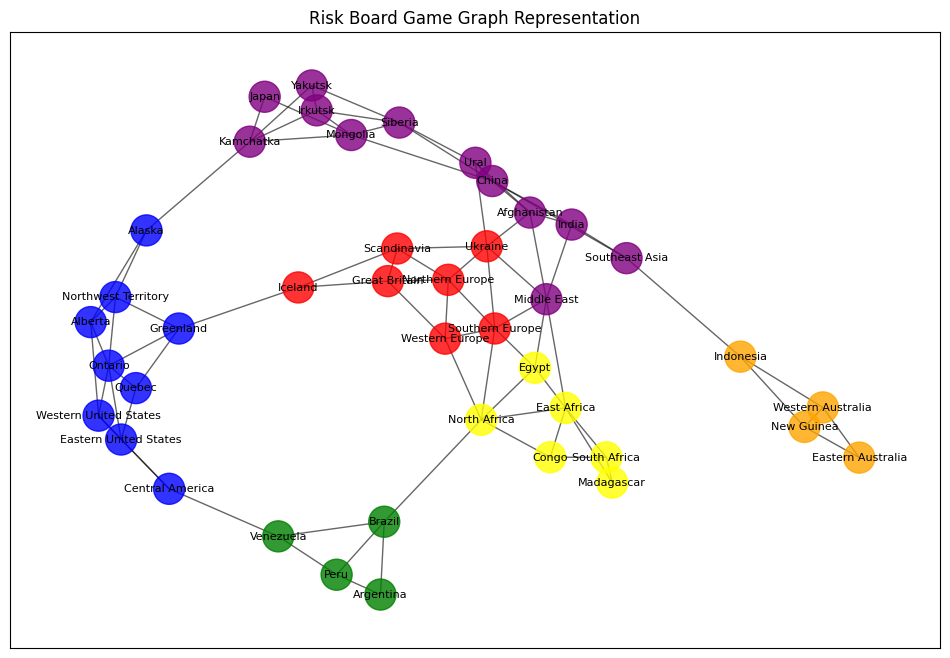

In [3]:
def create_risk_graph(territories):
    """
    Create a NetworkX graph from the Risk territory definitions.
    
    Parameters:
        territories (dict): Dictionary containing territory and connection information.
        
    Returns:
        G (nx.Graph): NetworkX graph representing the Risk board.
    """
    G = nx.Graph()

    for continent, territory_list in territories.items():
        for territory, neighbors in territory_list.items():
            G.add_node(territory, continent=continent)

            for neighbor in neighbors:
                G.add_edge(territory, neighbor)

    return G

def draw_risk_graph(G):
    """
    Draw the Risk game graph using NetworkX and Matplotlib.
    
    Parameters:
        G (nx.Graph): The Risk board graph.
    """
    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(G, seed=42)  

    continent_colors = {
        'North America': 'blue',
        'South America': 'green',
        'Europe': 'red',
        'Africa': 'yellow',
        'Asia': 'purple',
        'Australia': 'orange'
    }

    node_colors = [continent_colors[G.nodes[node]['continent']] for node in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="black")

    plt.title("Risk Board Game Graph Representation")
    plt.show()

# Create the Risk graph
G = create_risk_graph(risk_territories)

# Draw the Risk game graph
draw_risk_graph(G)

### Graph Visualization

&#9989; **Question 3.3 (4 points)**: Create a visualization of the Risk board graph. You can use AI to help you with this. The function below should:

- make a plot of the risk graph.
- color nodes by continent
- allow the user to choose a type of layout. _Hint:_ search networkx documentation for the possible layout. Min 5 layouts should be available.
- print the name of each territory on the respective node
- make a legend for the graph 
- have very descriptive comments 
- increase the size of each node from the default value  
- increase the font size of label from the default value

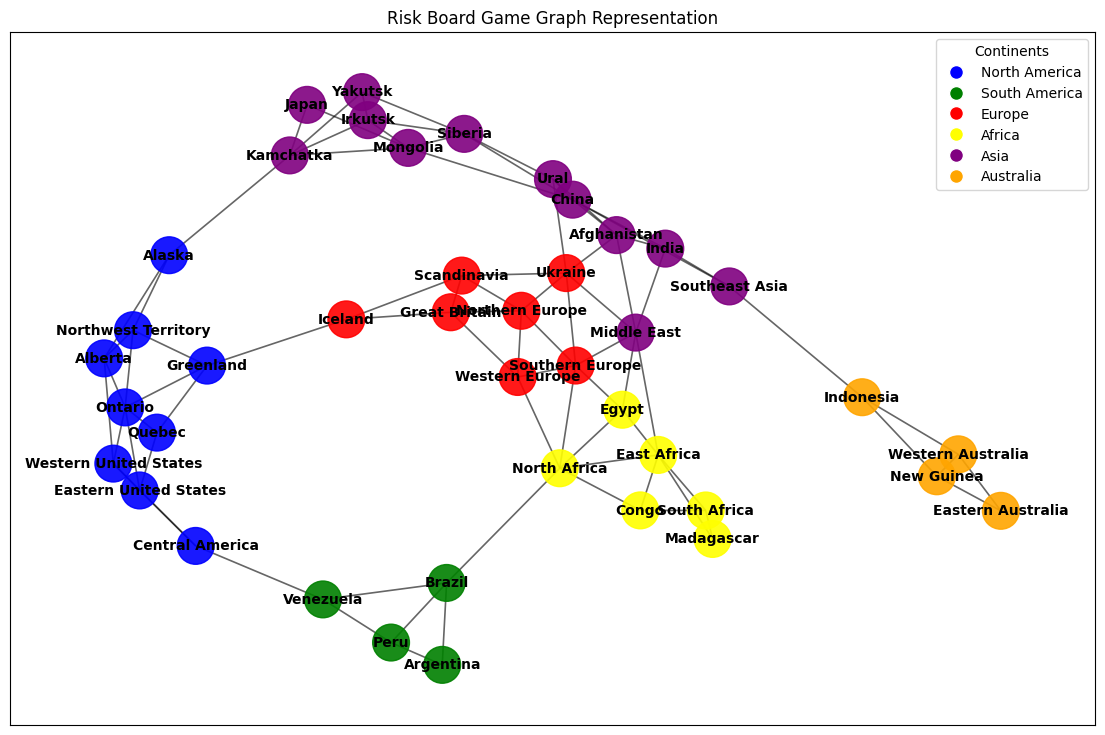

In [4]:
def visualize_risk_graph(G, layout_type="spring"):
    """
    Create a visualization of the Risk board graph with continents colored differently.

    Parameters:
        G (nx.Graph): NetworkX graph of the Risk board.
        layout_type (str): The type of layout for node positioning. Options: 'spring', 'circular', 
                           'kamada_kawai', 'random', 'shell'.
    """
    plt.figure(figsize=(14, 9))

    # Define available layouts
    layouts = {
        "spring": nx.spring_layout(G, seed=42),
        "circular": nx.circular_layout(G),
        "kamada_kawai": nx.kamada_kawai_layout(G),
        "random": nx.random_layout(G, seed=42),
        "shell": nx.shell_layout(G)
    }

    # Select the layout based on user input
    pos = layouts.get(layout_type, nx.spring_layout(G, seed=42))

    # Define colors for each continent
    continent_colors = {
        'North America': 'blue',
        'South America': 'green',
        'Europe': 'red',
        'Africa': 'yellow',
        'Asia': 'purple',
        'Australia': 'orange'
    }

    # Assign colors to nodes based on their continent
    node_colors = [continent_colors[G.nodes[node]['continent']] for node in G.nodes]

    # Draw the graph nodes with increased size and transparency
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.9)
    
    # Draw the edges connecting the territories
    nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.6)
    
    # Draw the labels (territory names) on the nodes with larger font size
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", font_weight="bold")

    # Create a legend for the continents with proper colors
    legend_labels = {continent: plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=color) 
                     for continent, color in continent_colors.items()}
    plt.legend(legend_labels.values(), legend_labels.keys(), loc="best", title="Continents")

    # Set the title and show the graph
    plt.title("Risk Board Game Graph Representation")
    plt.show()

# Visualize the graph using the default "spring" layout
visualize_risk_graph(G)



&#9989; **Question 3.4 (26 points)**: Answer the following questions based on the Risk board graph visualization. Each answer should have a minimum of 1-2 sentences and snippet of the code that supports your answer. You must explain what each function in the code snippet does. 

All answers should be in the same markdown cell. 

The code snippet should be properly displayed using code markdown. 

1. Which layout type provides the best visualization of the continent-based clustering in the Risk board graph?
    - Explain the rationale behind your choice of layout.
2. Do a little research and explain what the Kamada-Kawai layout does? Make sure to cite your sources.
3. Which part of the code is used to assign the color of each node based on its continent?
4. How did you make the legend? Explain any non-obvious part of the code.
5. What colormap did you choose for the continents and how did you import the colormap? 
6. How did you set the node size and font size in the visualization?
7. How did you print the labels for the nodes? 

✎ 1. Which layout type provides the best visualization of the continent-based clustering in the Risk board graph? The spring layout is best because it spreads out the nodes while keeping connected ones close together. This makes it easier to see groups of territories in each continent.

pos = nx.spring_layout(G, seed=42)
This makes sure connected territories are near each other.

    1A. Explain the rationale behind your choice of layout. The spring layout naturally groups territories together while keeping them from overlapping. It makes it easy to see which territories belong to which continent.

2. Do a little research and explain what the Kamada-Kawai layout does? The Kamada-Kawai layout arranges nodes so that they are spaced out evenly. It makes the graph smooth and readable by adjusting distances between connected nodes.

pos = nx.kamada_kawai_layout(G)
This layout spreads the territories in a way that looks balanced.

3. Which part of the code is used to assign the color of each node based on its continent? The code below gives each continent a color and applies it to its territories.

continent_colors = {
    'North America': 'blue',
    'South America': 'green',
    'Europe': 'red',
    'Africa': 'yellow',
    'Asia': 'purple',
    'Australia': 'orange'
}
node_colors = [continent_colors[G.nodes[node]['continent']] for node in G.nodes]
This makes sure each continent has a different color.

4. How did you make the legend? The legend is made by creating small colored circles for each continent and placing them in the graph.

legend_labels = {continent: plt.Line2D([0], [0], marker='o', color='w', 
                                       markersize=10, markerfacecolor=color) 
                 for continent, color in continent_colors.items()}
plt.legend(legend_labels.values(), legend_labels.keys(), loc="best", title="Continents")
Each continent gets a matching colored dot in the legend.

5. What colormap did you choose for the continents and how did you import the colormap? I used manual colors instead of a colormap. Each continent was assigned a fixed color like this:

continent_colors = {
    'North America': 'blue',
    'South America': 'green',
    'Europe': 'red',
    'Africa': 'yellow',
    'Asia': 'purple',
    'Australia': 'orange'
}
This way, each continent always has the same color.

6. How did you set the node size and font size in the visualization? The nodes are bigger to make them easy to see, and the text is larger so it’s readable.

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", font_weight="bold")
This makes everything easier to see.

7. How did you print the labels for the nodes? The function below places territory names on the nodes.

nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", font_weight="bold")
This makes sure every territory name appears on the graph.

---
## &#128721; STOP
**Pause to commit your changes to your Git repository! (1 points)**

Take a moment to save your notebook, commit the changes to your Git repository using the commit message "**Committing Part 3**", no need to push the changes to GitHub yet, but you can if you want.

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [5]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://forms.office.com/r/mB0YjLYvAA" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

If you like, you can upload this file to D2L for a record. Nevertheless, **we will grade the copy on GitHub**. 


&#169; Copyright 2025,  Department of Computational Mathematics, Science and Engineering at Michigan State University